# 放熱の基礎 I Notebook：1次元フィン

対応章：[放熱の基礎 I](../chapters/11_stegosaurus_heat_basic.md)

根元温度を固定し，先端を断熱した1次元フィンを計算する．温度と放熱量を解析解で検証してから，長さと対流係数を別々に変える．以下の値は計算練習用であり，背板の実測値ではない．

## ライブラリ読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

Matplotlib is building the font cache; this may take a moment.


## パラメータ設定

In [2]:
k     = 20.0    # thermal conductivity [W/(m K)]
h     = 25.0    # convection coefficient [W/(m^2 K)]
T_b   = 40.0    # base temperature [degC]
T_air = 25.0    # air temperature [degC]
width = 0.30    # width [m]
thick = 0.03    # thickness [m]
L     = 0.40    # length [m]

A_c = width * thick
P = 2 * (width + thick)
m = np.sqrt(h * P / (k * A_c))
theta_b = T_b - T_air
print(f'm = {m:.3f} [1/m], mL = {m*L:.3f}, Bi_perp = {h*A_c/(P*k):.4f}')

m = 9.574 [1/m], mL = 3.830, Bi_perp = 0.0170


## 解析解と差分法

解析解 $\theta(x)=\theta_b\cosh(m(L-x))/\cosh(mL)$ と差分解を比較する．先端では中央差分の断熱条件から補助点を消去し，$2\theta_{N-1}-(2+(m\Delta x)^2)\theta_N=0$ を使う．`n` は両端を含む点の数なので，区間数は `n-1` である．

`Q_fin` は引数だけで放熱量を計算する．`h` を変えるときには `m` も変える必要がある．

In [3]:
def theta_analytic(x, L, m, theta_b):
    x = np.asarray(x)
    # cosh(m*(L-x))/cosh(m*L) と等価な式で，指数のオーバーフローを避ける．
    return theta_b * (np.exp(-m*x) + np.exp(-m*(2*L-x))) / (1 + np.exp(-2*m*L))


def theta_fd(L, m, theta_b, n=101):
    if L <= 0 or m < 0 or n < 3:
        raise ValueError('Require L > 0, m >= 0, n >= 3')
    x = np.linspace(0, L, n)
    dx = x[1] - x[0]
    A = np.zeros((n, n))
    b = np.zeros(n)
    A[0, 0] = 1.0
    b[0] = theta_b
    for i in range(1, n - 1):
        A[i, i - 1] = 1.0
        A[i, i] = -2.0 - (m * dx)**2
        A[i, i + 1] = 1.0
    # 補助点 theta[n] = theta[n-2] を先端の差分式へ代入する．
    A[-1, -2] = 2.0
    A[-1, -1] = -2.0 - (m * dx)**2
    return x, np.linalg.solve(A, b)


def Q_fin(L, m, theta_b, k, A_c):
    # k*A_c*m = sqrt(h*P*k*A_c)．h を変える場合は m を再計算する．
    # 関数の外にある h を参照しない．
    return k * A_c * m * theta_b * np.tanh(m * L)


x = np.linspace(0, L, 101)
theta_exact = theta_analytic(x, L, m, theta_b)
x_fd, theta_num = theta_fd(L, m, theta_b)
print('max temperature error [K] =', np.max(np.abs(theta_num - theta_exact)))

max temperature error [K] = 0.00034369870776895795


## 温度分布の図

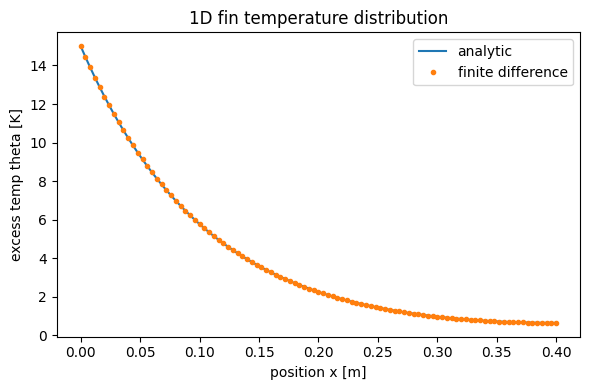

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(x, theta_exact, label='analytic')
plt.plot(x_fd, theta_num, 'o', ms=3, label='finite difference')
plt.xlabel('position x [m]'); plt.ylabel('excess temp theta [K]')
plt.title('1D fin temperature distribution')
plt.legend(); plt.tight_layout(); plt.show()

## フィン長を変えた比較

`k, h, P, A_c, theta_b` を固定し，`L` だけを変える．$Q=kA_cm\theta_b\tanh(mL)$，$\eta=\tanh(mL)/(mL)$ を用いる．同じ体積での比較ではない．

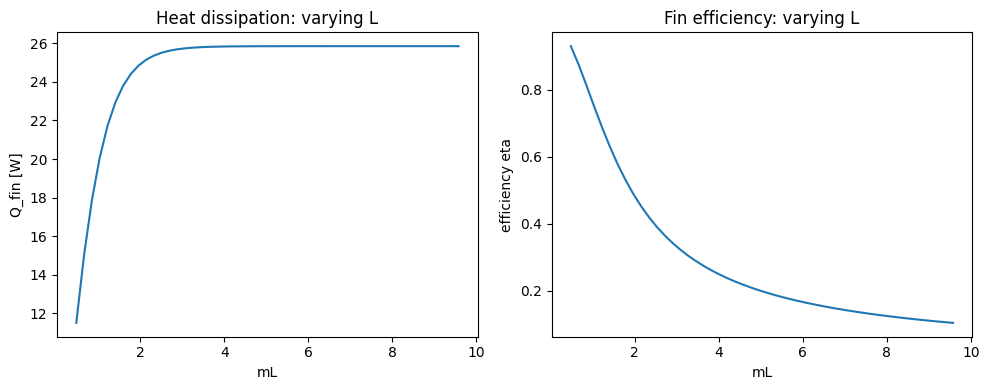

In [5]:
Ls = np.linspace(0.05, 1.0, 50)
mL = m * Ls
Q = Q_fin(Ls, m, theta_b, k, A_c)
eta = np.tanh(mL) / mL
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(mL, Q)
ax[0].set(xlabel='mL', ylabel='Q_fin [W]', title='Heat dissipation: varying L')
ax[1].plot(mL, eta)
ax[1].set(xlabel='mL', ylabel='efficiency eta', title='Fin efficiency: varying L')
plt.tight_layout()
plt.show()

## 格子幅と誤差の関係

温度の相対最大誤差，根元の片側差分と側面の台形積分による放熱量誤差を計算する．温度の観測収束次数が約2へ近づくか確認する．根元熱流と側面積分は異なる近似なので，有限格子では完全には一致しない．

In [6]:
rows = []
q_exact = Q_fin(L, m, theta_b, k, A_c)
for n in [21, 41, 81, 161]:
    x_grid, theta_grid = theta_fd(L, m, theta_b, n=n)
    dx = x_grid[1] - x_grid[0]
    error = np.max(np.abs(theta_grid - theta_analytic(x_grid, L, m, theta_b))) / theta_b
    q_base = -k*A_c*(-3*theta_grid[0] + 4*theta_grid[1] - theta_grid[2]) / (2*dx)
    q_side = h*P*trapezoid(theta_grid, x_grid)
    rows.append({'n': n, 'dx [m]': dx, 'relative T error': error,
                 'Q_base [W]': q_base, 'Q_side [W]': q_side,
                 'relative Q_base error': abs(q_base-q_exact)/q_exact,
                 'relative Q_side error': abs(q_side-q_exact)/q_exact})
fin_convergence = pd.DataFrame(rows)
fin_convergence['observed T order'] = np.log2(
    fin_convergence['relative T error'].shift(1) / fin_convergence['relative T error'])
fin_convergence

,n,dx [m],relative T error,Q_base [W],Q_side [W],relative Q_base error,relative Q_side error,observed T order
0,21,0.0200,0.000570,25.513711,25.943975,0.012098,0.004562,NaN
1,41,0.0100,0.000143,25.742833,25.855666,0.003227,0.001142,1.993832
2,81,0.0050,0.000036,25.804649,25.833541,0.000833,0.000286,1.998822
3,161,0.0025,0.000009,25.820697,25.828007,0.000212,0.000071,1.999554


## 課題：関数の実装と検証

1. `fin_summary(target_mL_values)` を作り，`mL`，対応する `L`，`Q_fin`，`eta` をDataFrameで返す．`[0.1, 1, 3, 10]` で実行する．ここでは `k, h, P, A_c, theta_b` を固定して長さだけを変える．
2. `compare_h_values(h_values)` を作り，長さを固定して `h` を変えたときの `m`，`mL`，`Q_fin`，`eta` を表にする．温度分布を1枚の図に重ね，`h` ごとに `m` を再計算する．
3. `h` を2倍にしたときの放熱量と効率の変化を確認する．計算した `Q_fin` が，別に計算した `sqrt(h*P*k*A_c)*theta_b*tanh(m*L)` と一致することを `np.testing.assert_allclose` で検証する．
4. `fin_grid_study(n_values)` を作り，温度の相対最大誤差，根元微分と側面積分から求めた放熱量の相対誤差，温度の観測収束次数を返す．`[21, 41, 81, 161]` で実行する．最初の格子では収束次数を定義できないため `NaN` とする．

In [7]:
# 課題実装セル
# fin_summary, compare_h_values, fin_grid_study を実装し，検証する．